<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Image Filtering
Image filtering consists of **convolving** the image with a specified kernel.

In [56]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [57]:
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/picture32.png
!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png

--2026-05-28 05:38:48--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/picture32.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 566322 (553K) [image/png]
Saving to: ‘picture32.png.1’

picture32.png.1     100%[===================>] 553.05K  --.-KB/s    in 0.1s    

2026-05-28 05:38:48 (4.51 MB/s) - ‘picture32.png.1’ saved [566322/566322]

--2026-05-28 05:38:48--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 736501 (719K) [image/png]
Saving

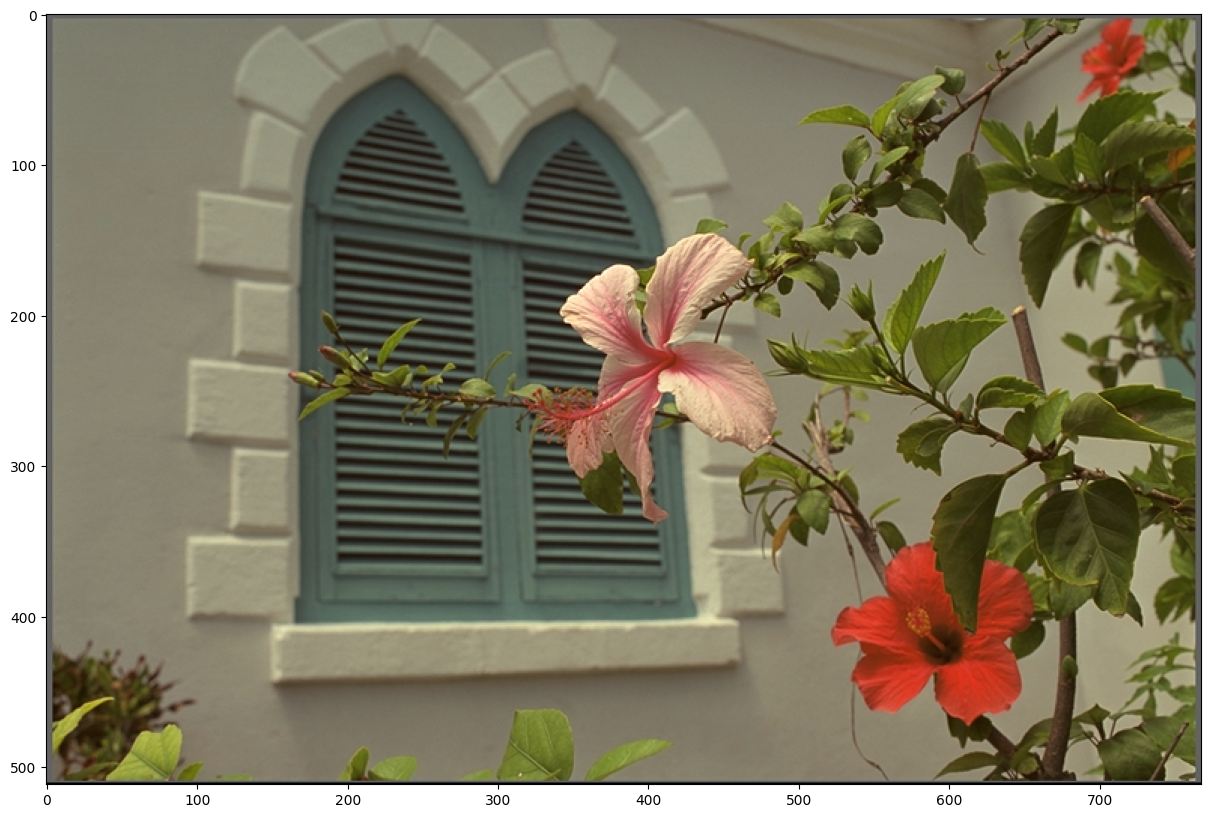

In [58]:
img = cv2.imread('picture32.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img)

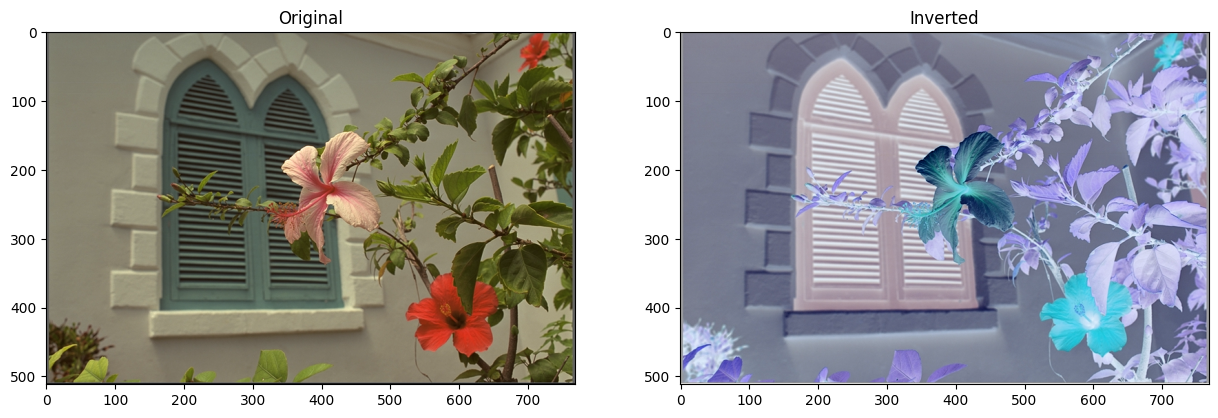

In [59]:
# a) Інвертування зображення

img_inv = 255 - img

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(img_inv), plt.title('Inverted')
plt.show()

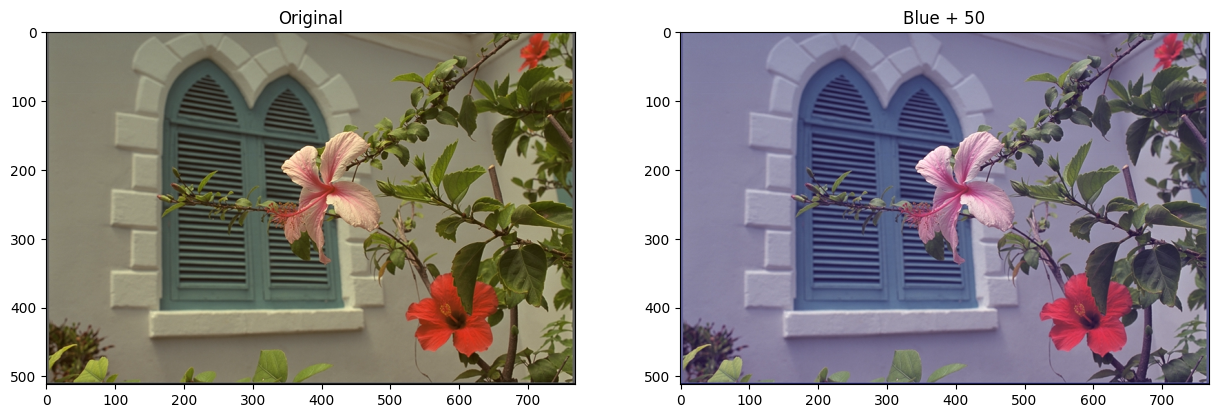

In [60]:
# b) Зміна однієї компоненти
# Наприклад, додамо 50 до Blue

img_blue = img.copy()
img_blue[:, :, 2] = np.clip(
    img_blue[:, :, 2].astype(np.int16) + 50,
    0,
    255
).astype(np.uint8)

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(img_blue), plt.title('Blue + 50')
plt.show()

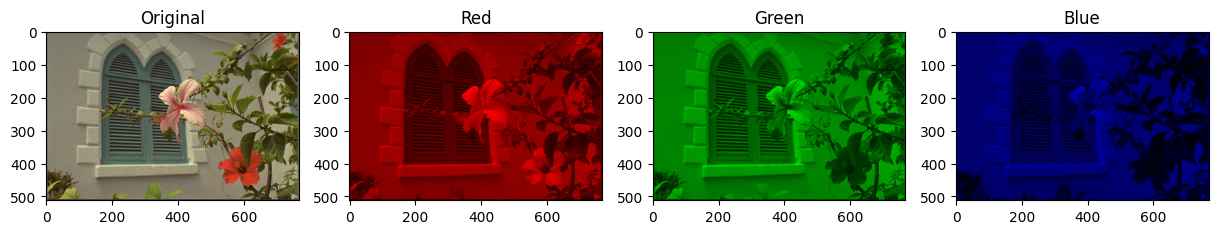

In [61]:
# c) Розбиття на Red, Green, Blue

red = np.zeros_like(img)
green = np.zeros_like(img)
blue = np.zeros_like(img)

red[:, :, 0] = img[:, :, 0]
green[:, :, 1] = img[:, :, 1]
blue[:, :, 2] = img[:, :, 2]

plt.subplot(141), plt.imshow(img), plt.title('Original')
plt.subplot(142), plt.imshow(red), plt.title('Red')
plt.subplot(143), plt.imshow(green), plt.title('Green')
plt.subplot(144), plt.imshow(blue), plt.title('Blue')
plt.show()

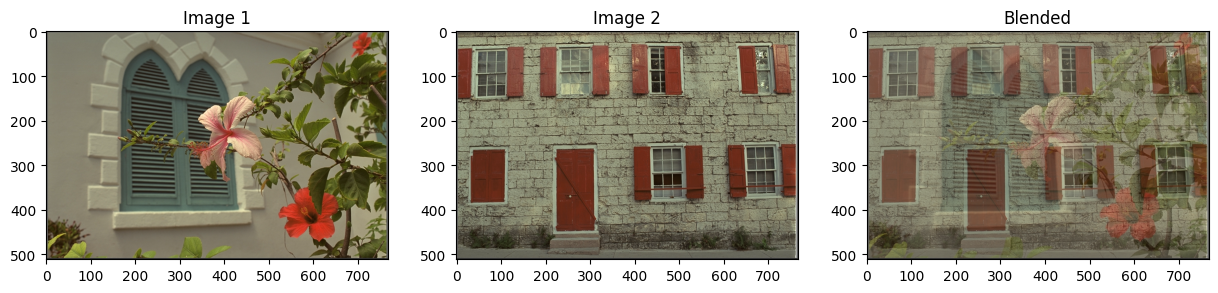

In [62]:
# d) Злиття двох зображень

img2 = cv2.imread('pic31.png')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img2 = cv2.resize(img2, (img.shape[1], img.shape[0]))

alpha = 0.4

img_blend = cv2.addWeighted(img, alpha, img2, 1 - alpha, 0)

plt.subplot(131), plt.imshow(img), plt.title('Image 1')
plt.subplot(132), plt.imshow(img2), plt.title('Image 2')
plt.subplot(133), plt.imshow(img_blend), plt.title('Blended')
plt.show()

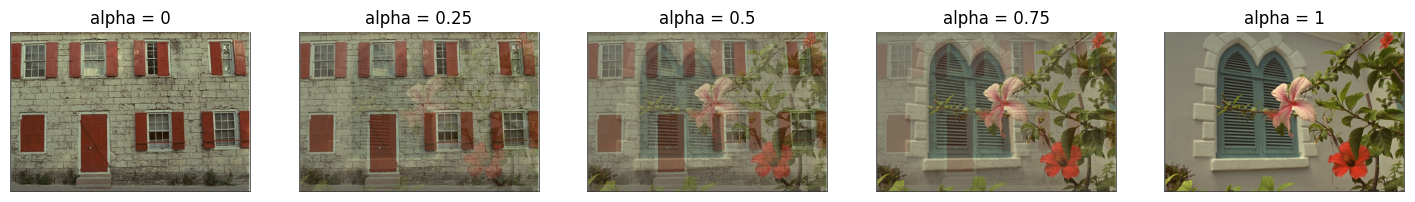

In [63]:
# d) Анімація alpha
alphas = [0, 0.25, 0.5, 0.75, 1]

plt.figure(figsize=(18, 5))

for i, alpha in enumerate(alphas):
    img_blend = cv2.addWeighted(img, alpha, img2, 1 - alpha, 0)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_blend)
    plt.title(f'alpha = {alpha}')
    plt.axis('off')

plt.show()

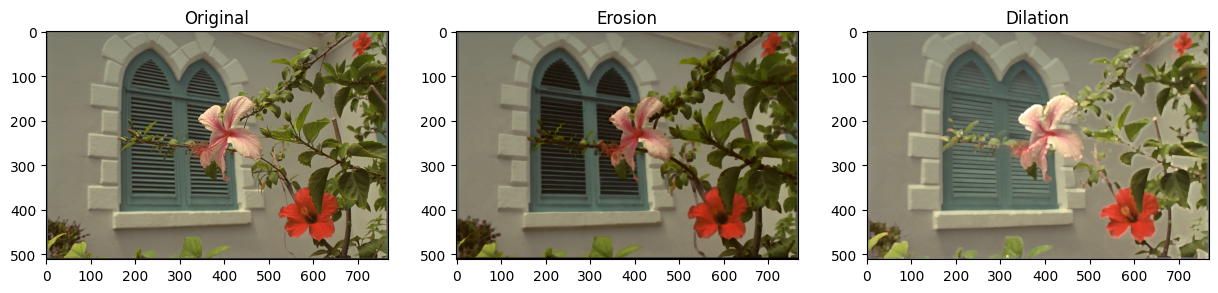

In [64]:
# e) Ерозія та нарощування

kernel = np.ones((5, 5), np.uint8)

erosion = cv2.erode(img, kernel)
dilation = cv2.dilate(img, kernel)

plt.subplot(131), plt.imshow(img), plt.title('Original')
plt.subplot(132), plt.imshow(erosion), plt.title('Erosion')
plt.subplot(133), plt.imshow(dilation), plt.title('Dilation')
plt.show()

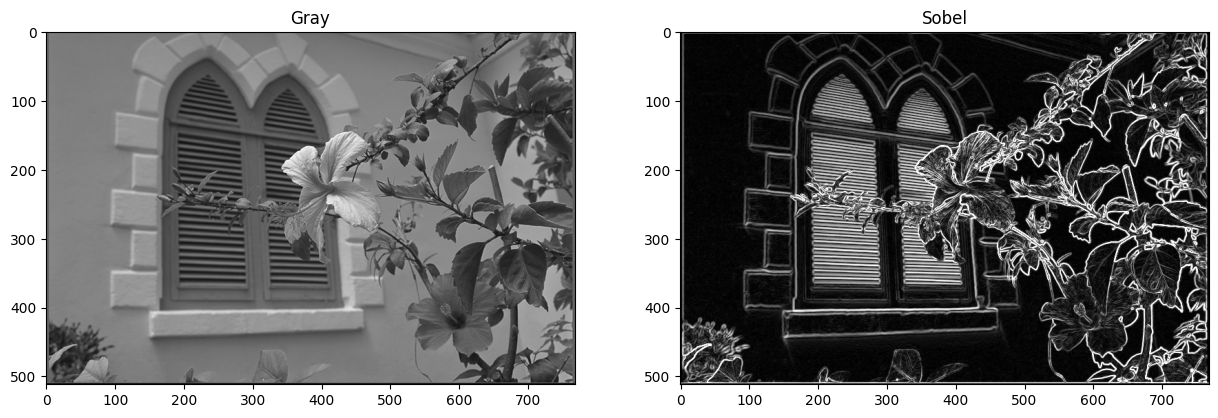

In [65]:
# e) Собель

sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = np.sqrt(sobel_x ** 2 + sobel_y ** 2)
sobel = np.clip(sobel, 0, 255).astype(np.uint8)

plt.subplot(121), plt.imshow(img_gray, cmap='gray'), plt.title('Gray')
plt.subplot(122), plt.imshow(sobel, cmap='gray'), plt.title('Sobel')
plt.show()

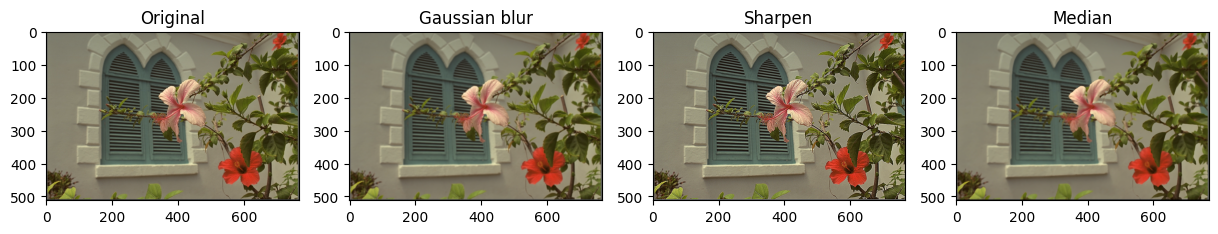

In [66]:
# e) Матричні фільтри: розмиття, чіткість, медіанний

blur = cv2.GaussianBlur(img, (5, 5), 0)

sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])
sharpen = cv2.filter2D(img, -1, sharpen_kernel)

median = cv2.medianBlur(img, 5)

plt.subplot(141), plt.imshow(img), plt.title('Original')
plt.subplot(142), plt.imshow(blur), plt.title('Gaussian blur')
plt.subplot(143), plt.imshow(sharpen), plt.title('Sharpen')
plt.subplot(144), plt.imshow(median), plt.title('Median')
plt.show()

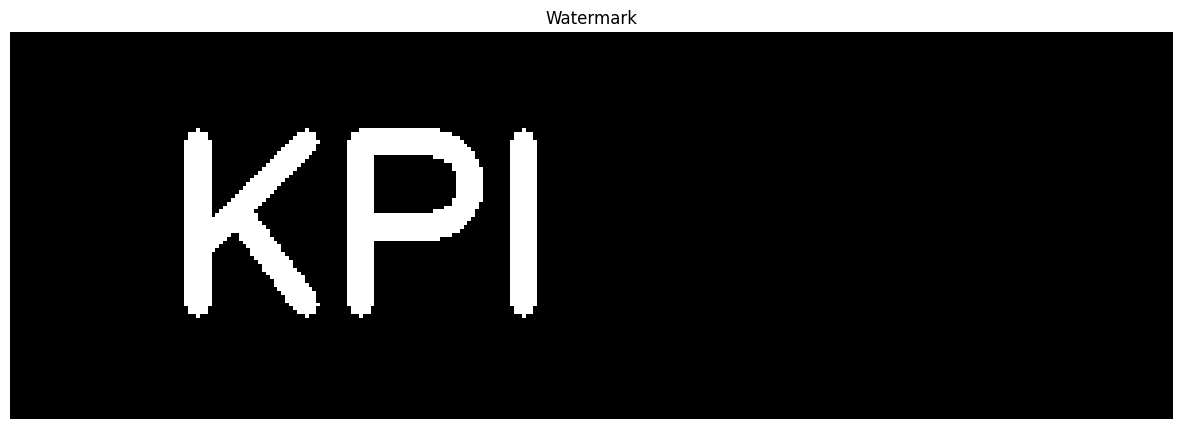

In [67]:
# f) Водяний знак

watermark = np.zeros((100, 300), dtype=np.uint8)

cv2.putText(
    watermark,
    'KPI',
    (40, 70),
    cv2.FONT_HERSHEY_SIMPLEX,
    2,
    255,
    5
)

plt.imshow(watermark, cmap='gray')
plt.title('Watermark')
plt.axis('off')
plt.show()


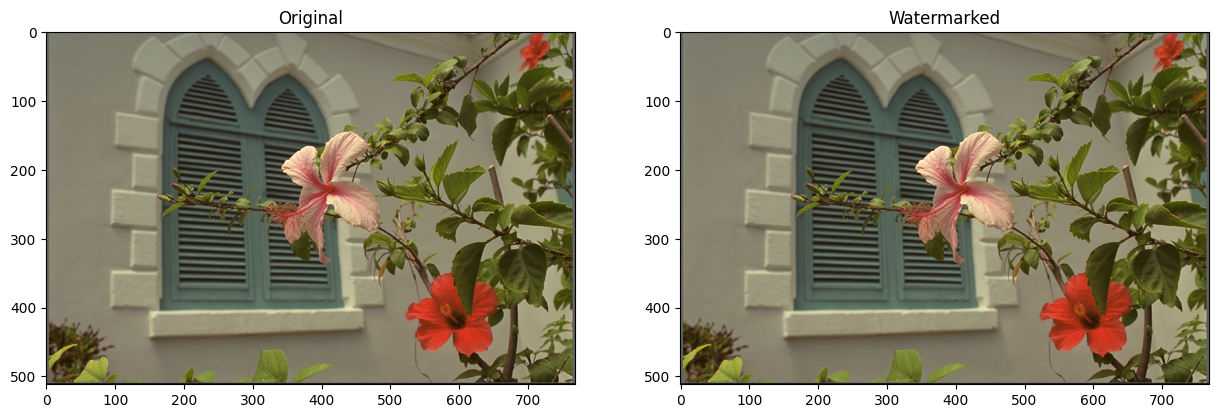

In [68]:
# f) Вбудовування водяного знаку у Blue канал методом LSB

bit_plane = 1
mask = 1 << (bit_plane - 1)

watermarked = img.copy()

h, w = img.shape[:2]
wh, ww = watermark.shape[:2]

for y in range(h):
    for x in range(w):
        wm_bit = 1 if watermark[y % wh, x % ww] > 127 else 0

        if wm_bit == 1:
            watermarked[y, x, 2] = watermarked[y, x, 2] | mask
        else:
            watermarked[y, x, 2] = watermarked[y, x, 2] & (255 - mask)

plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(watermarked), plt.title('Watermarked')
plt.show()


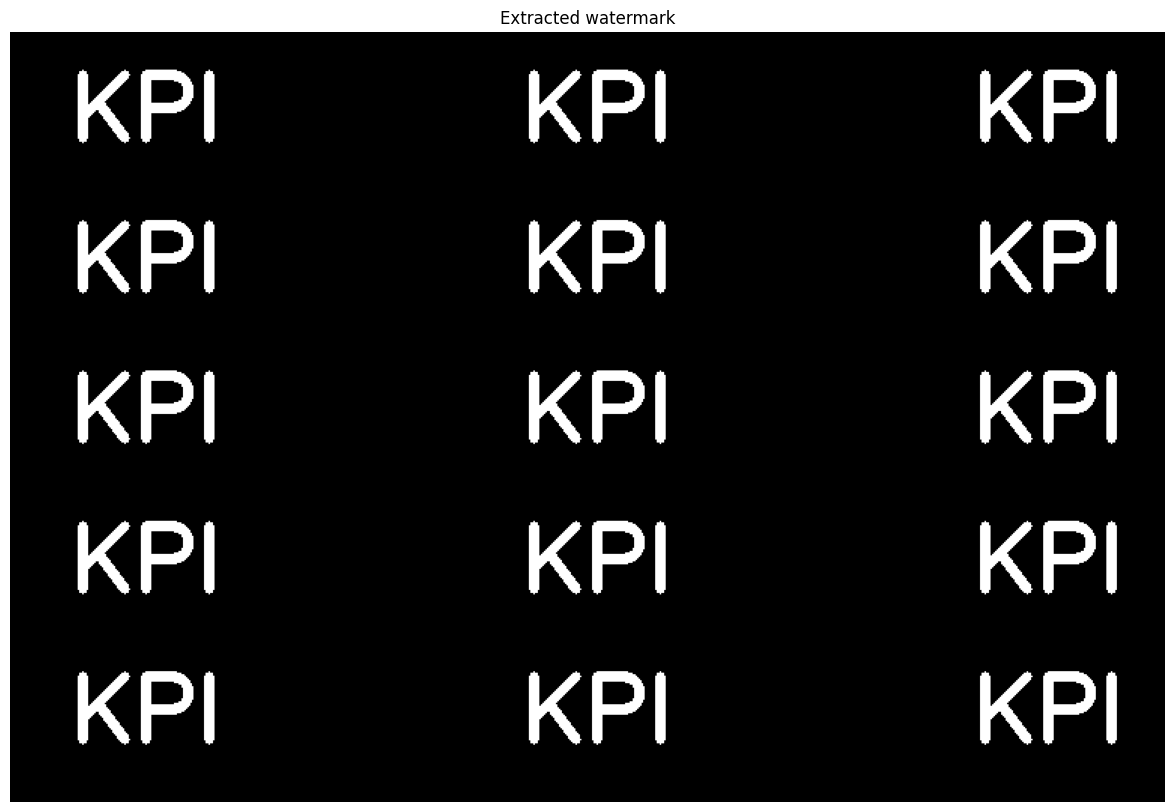

In [69]:
# g) Вилучення водяного знаку

extracted = np.zeros((h, w), dtype=np.uint8)

for y in range(h):
    for x in range(w):
        bit = watermarked[y, x, 2] & mask

        if bit > 0:
            extracted[y, x] = 255
        else:
            extracted[y, x] = 0

plt.imshow(extracted, cmap='gray')
plt.title('Extracted watermark')
plt.axis('off')
plt.show()
